In [ ]:
# Cell 1 — Installs
!pip install pandas numpy scikit-learn --quiet

In [ ]:
# Cell 0 — Remerge all 10 CICIDS2018 CSV files
import pandas as pd
import os

csv_files = sorted([
    f for f in os.listdir("archive")
    if f.endswith(".csv")
    and f != "full_df_binary_labels.csv"
])

print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  {f}")

output_file = "archive/full_df_binary_labels.csv"

# Delete old merged file
if os.path.exists(output_file):
    os.remove(output_file)
    print(f"\nDeleted old merged file")

first = True
total_rows = 0

for file in csv_files:
    print(f"\nProcessing {file}...")
    file_rows = 0
    for chunk in pd.read_csv(
            f"archive/{file}",
            chunksize=100_000,
            low_memory=False,
            on_bad_lines="skip"):

        # Normalize label column
        for col in chunk.columns:
            if col.lower() in ["label", "labels",
                                "attack", "class"]:
                chunk.rename(
                    columns={col: "label"},
                    inplace=True)
                break

        # Add binary label
        if "label" in chunk.columns:
            chunk["Label_Binary"] = chunk["label"].apply(
                lambda x: 0 if str(x).strip().lower()
                == "benign" else 1
            )

        chunk.to_csv(output_file, mode="a",
                     index=False, header=first)
        first = False
        file_rows  += len(chunk)
        total_rows += len(chunk)

    print(f"  {file_rows:,} rows")

print(f"\nTotal rows merged: {total_rows:,}")
print(f"Saved to: {output_file}")

# Verify
df_check = pd.read_csv(output_file, nrows=5)
print(f"\nColumns: {list(df_check.columns)}")

In [ ]:
!pip install pandas


In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy

In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn

In [1]:
# Cell 2 — Imports
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from shared.config import (DATA_PATH, CHUNK_SIZE, RANDOM_STATE,
                            OUTPUT_DIR, MODEL_DIR)
print("Imports OK")

Config loaded successfully
Imports OK


In [2]:
# Cell 3 — Full cleaning pipeline (replicates Zied's 3-phase cleaning)
import os
import gc

print("Starting full cleaning pipeline...")

# ── Features to remove (Zied's analysis) ────────────────────
FEATURES_TO_REMOVE = [
    # Zero importance
    'Bwd PSH Flags', 'Bwd URG Flags',
    'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg',
    'Bwd Byts/b Avg', 'Bwd Pkts/b Avg',
    'Bwd Blk Rate Avg', 'Fwd Byts/b Avg',
    # Identifiers
    'Flow ID', 'Src IP', 'Dst IP', 'Src Port',
    # Near-zero importance
    'CWE Flag Count', 'Fwd URG Flags', 'Pkt Len Min',
    'Active Std', 'Fwd PSH Flags', 'Idle Std',
    'SYN Flag Cnt', 'FIN Flag Cnt', 'Bwd Pkt Len Min',
    'Active Mean', 'Active Max', 'Fwd Pkt Len Min',
    'Active Min',
    # Data leakage
    'Timestamp'
]

# ── Get all 10 raw CSV files ─────────────────────────────────
csv_files = sorted([
    f for f in os.listdir("archive")
    if f.endswith(".csv")
    and f != "full_df_binary_labels.csv"
])

print(f"Found {len(csv_files)} CSV files")

output_file = "archive/full_df_binary_labels.csv"
if os.path.exists(output_file):
    os.remove(output_file)
    print("Deleted old merged file")

first_write = True
total_rows  = 0
invalid_rows = 0

for file in csv_files:
    path = f"archive/{file}"
    print(f"\nProcessing {file}...")
    file_rows = 0

    for chunk in pd.read_csv(
            path,
            chunksize=CHUNK_SIZE,
            low_memory=False,
            on_bad_lines="skip"):

        # Normalize column names
        chunk.columns = chunk.columns.str.strip()

        # Find label column
        label_col = None
        for col in chunk.columns:
            if col.lower() in ["label", "labels"]:
                label_col = col
                break

        if label_col is None:
            continue

        # Remove rows with invalid label
        # (rows where label == "Label" are duplicate headers)
        chunk = chunk[
            chunk[label_col].astype(str).str.strip()
            != "Label"
        ].copy()

        if len(chunk) == 0:
            continue

        # Remove unwanted features
        cols_to_drop = [c for c in FEATURES_TO_REMOVE
                        if c in chunk.columns]
        chunk = chunk.drop(columns=cols_to_drop,
                           errors="ignore")

        # Fix numeric columns
        numeric_cols = chunk.select_dtypes(
            include=[np.number]).columns
        for col in numeric_cols:
            chunk[col] = chunk[col].replace(
                [np.inf, -np.inf], np.nan)
            chunk[col] = chunk[col].fillna(0)

        # Add binary label
        chunk["Label_Binary"] = chunk[label_col].apply(
            lambda x: 0 if str(x).strip().lower()
            == "benign" else 1
        )

        # Rename label column to standard name
        chunk = chunk.rename(
            columns={label_col: "label"})

        chunk.to_csv(output_file, mode="a",
                     index=False, header=first_write)
        first_write = False
        file_rows  += len(chunk)
        total_rows += len(chunk)

    print(f"  {file_rows:,} rows")

print(f"\nTotal rows saved : {total_rows:,}")
print(f"Output           : {output_file}")

Starting full cleaning pipeline...
Found 10 CSV files
Deleted old merged file

Processing 02-14-2018.csv...
  1,048,575 rows

Processing 02-15-2018.csv...
  1,048,575 rows

Processing 02-16-2018.csv...
  1,048,574 rows

Processing 02-20-2018.csv...
  7,948,748 rows

Processing 02-21-2018.csv...
  1,048,575 rows

Processing 02-22-2018.csv...
  1,048,575 rows

Processing 02-23-2018.csv...
  1,048,575 rows

Processing 02-28-2018.csv...
  613,071 rows

Processing 03-01-2018.csv...
  331,100 rows

Processing 03-02-2018.csv...
  1,048,575 rows

Total rows saved : 16,232,943
Output           : archive/full_df_binary_labels.csv


In [2]:
# Cell 3b — Load cleaned file into memory
print("Loading cleaned dataset into memory...")
chunks = []

for chunk in pd.read_csv(
        "archive/full_df_binary_labels.csv",
        chunksize=CHUNK_SIZE,
        low_memory=False,
        on_bad_lines="skip"):
    chunks.append(chunk)

df_full = pd.concat(chunks, ignore_index=True)
del chunks
import gc
gc.collect()

print(f"Shape       : {df_full.shape}")
print(f"Class dist  :\n{df_full['Label_Binary'].value_counts()}")
print(f"Benign ratio: {(df_full['Label_Binary']==0).mean()*100:.1f}%")
print(f"Attack ratio: {(df_full['Label_Binary']==1).mean()*100:.1f}%")

Loading cleaned dataset into memory...
Shape       : (16232943, 59)
Class dist  :
Label_Binary
0    13484708
1     2748235
Name: count, dtype: int64
Benign ratio: 83.1%
Attack ratio: 16.9%


In [3]:
# Free memory before feature engineering
import gc

# Delete any leftover variables from previous runs
try: del X_full
except: pass
try: del y_full
except: pass
try: del X_train
except: pass
try: del X_val
except: pass
try: del X_test
except: pass
try: del y_train
except: pass
try: del y_val
except: pass
try: del y_test
except: pass

gc.collect()
print(f"Memory freed")

Memory freed


In [4]:
# Cell 4 — Feature engineering + cleaning (enhanced)

import gc

# ── Step 1: Convert all columns to numeric first ─────────────
# Must do this BEFORE corrupt row check
# Some columns may contain strings due to CSV parsing issues
print("Converting columns to numeric...")
for col in df_full.columns:
    if col not in ["label", "Label_Binary"]:
        df_full[col] = pd.to_numeric(df_full[col],
                                      errors="coerce")
print("Conversion done")

# ── Step 2: Remove corrupt rows (CICFlowMeter known bug) ────
NON_NEGATIVE_FEATURES = [
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Flow IAT Max',  'Flow IAT Min',  'Fwd IAT Tot',
    'Fwd IAT Mean',  'Fwd IAT Std',   'Fwd IAT Max',
    'Fwd IAT Min',   'Bwd IAT Tot',   'Bwd IAT Mean',
    'Bwd IAT Std',   'Bwd IAT Max',   'Bwd IAT Min',
    'Idle Mean',     'Idle Max',      'Idle Min',
    'Tot Fwd Pkts',  'Tot Bwd Pkts',  'TotLen Fwd Pkts',
    'TotLen Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s'
]

before       = len(df_full)
cols_check   = [c for c in NON_NEGATIVE_FEATURES
                if c in df_full.columns]
corrupt_mask = (df_full[cols_check] < 0).any(axis=1)
df_full      = df_full[~corrupt_mask].copy()
print(f"Corrupt rows removed : {before - len(df_full):,}")
print(f"Remaining rows       : {len(df_full):,}")

# ── Step 3: Separate features and labels ─────────────────────
X_full = df_full.drop(["label", "Label_Binary"], axis=1)
y_full = df_full["Label_Binary"]
del df_full
gc.collect()

# ── Step 4: inf/nan cleanup ───────────────────────────────────
X_full = X_full.replace([np.inf, -np.inf], np.nan)

cols_before = X_full.shape[1]
X_full = X_full.dropna(axis=1, how="all")
print(f"Dropped {cols_before - X_full.shape[1]} all-NaN columns")

# ── Step 5: Drop correlated features (23 redundant) ──────────
CORRELATION_DROP = [
    'Subflow Fwd Pkts', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
    'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'TotLen Bwd Pkts',
    'ECE Flag Cnt',     'Tot Fwd Pkts',     'Bwd Header Len',
    'Idle Min',         'Fwd IAT Tot',      'Idle Mean',
    'Subflow Bwd Byts', 'Pkt Len Mean',     'Flow IAT Min',
    'Fwd Header Len',   'Fwd IAT Max',      'Flow IAT Mean',
    'Fwd IAT Min',      'Bwd Pkt Len Std',  'Pkt Len Std',
    'Fwd Pkt Len Std',  'Bwd Pkt Len Max'
]

cols_to_drop = [c for c in CORRELATION_DROP
                if c in X_full.columns]
X_full = X_full.drop(columns=cols_to_drop)
print(f"Correlated features dropped : {len(cols_to_drop)}")
print(f"Features remaining          : {X_full.shape[1]}")

# ── Step 6: Drop zero-variance features ──────────────────────
constant_cols = [c for c in X_full.columns
                 if X_full[c].std() < 1e-10]
if constant_cols:
    X_full = X_full.drop(columns=constant_cols)
    print(f"Zero-variance dropped: {len(constant_cols)}")
else:
    print("No zero-variance features found")

# ── Step 7: Fill NaN + memory optimization ───────────────────
X_full = X_full.fillna(X_full.median())
X_full = X_full.astype("float32")

print(f"\nFinal features shape : {X_full.shape}")
print(f"Memory usage         : "
      f"{X_full.memory_usage().sum() / 1e9:.2f} GB")

Converting columns to numeric...
Conversion done
Corrupt rows removed : 15
Remaining rows       : 16,232,928
Dropped 0 all-NaN columns
Correlated features dropped : 23
Features remaining          : 34
No zero-variance features found

Final features shape : (16232928, 34)
Memory usage         : 2.34 GB


In [5]:
# Cell 5 — 70/15/15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, y_full,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_full
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train : {X_train.shape} | "
      f"Attack ratio: "
      f"{y_train.mean()*100:.1f}%")
print(f"Val   : {X_val.shape}   | "
      f"Attack ratio: "
      f"{y_val.mean()*100:.1f}%")
print(f"Test  : {X_test.shape}  | "
      f"Attack ratio: "
      f"{y_test.mean()*100:.1f}%")

Train : (11363049, 34) | Attack ratio: 16.9%
Val   : (2434939, 34)   | Attack ratio: 16.9%
Test  : (2434940, 34)  | Attack ratio: 16.9%


In [6]:
# Cell 6 — Scale + save splits (PowerTransformer, no leakage)
from sklearn.preprocessing import PowerTransformer, StandardScaler
import pickle

POWER_TRANSFORMER_FEATURES = [
    'Dst Port', 'Flow Duration',
    'TotLen Fwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
    'Flow IAT Std', 'Flow IAT Max',
    'Fwd IAT Mean', 'Fwd IAT Std',
    'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std',
    'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd Pkts/s', 'Bwd Pkts/s',
    'Pkt Len Max', 'Pkt Len Var', 'Down/Up Ratio',
    'Pkt Size Avg', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Fwd Act Data Pkts', 'Idle Max', 'Tot Bwd Pkts'
]
STANDARD_SCALER_FEATURES = ['Fwd Seg Size Min']

X_train_s = X_train.copy()
X_val_s   = X_val.copy()
X_test_s  = X_test.copy()

# PowerTransformer — fit on train only
power_cols = [c for c in POWER_TRANSFORMER_FEATURES
              if c in X_train_s.columns
              and X_train_s[c].std() > 1e-10]
if power_cols:
    pt = PowerTransformer(method='yeo-johnson',
                           standardize=True)
    pt.fit(X_train_s[power_cols])
    X_train_s[power_cols] = pt.transform(
        X_train_s[power_cols])
    X_val_s[power_cols]   = pt.transform(
        X_val_s[power_cols])
    X_test_s[power_cols]  = pt.transform(
        X_test_s[power_cols])
    print(f"PowerTransformer : {len(power_cols)} features")

# StandardScaler — fit on train only
std_cols = [c for c in STANDARD_SCALER_FEATURES
            if c in X_train_s.columns
            and X_train_s[c].std() > 1e-10]
if std_cols:
    ss = StandardScaler()
    ss.fit(X_train_s[std_cols])
    X_train_s[std_cols] = ss.transform(X_train_s[std_cols])
    X_val_s[std_cols]   = ss.transform(X_val_s[std_cols])
    X_test_s[std_cols]  = ss.transform(X_test_s[std_cols])
    print(f"StandardScaler   : {len(std_cols)} features")

# Save splits
splits = {
    "X_train": X_train_s,
    "X_val"  : X_val_s,
    "X_test" : X_test_s,
    "y_train": y_train,
    "y_val"  : y_val,
    "y_test" : y_test,
}
with open("models/splits.pkl", "wb") as f:
    pickle.dump(splits, f)

# Save scalers
scalers = {}
if power_cols: scalers["power"] = pt
if std_cols:   scalers["standard"] = ss
with open("models/scalers.pkl", "wb") as f:
    pickle.dump(scalers, f)

print(f"\nSplits saved — features : {X_train_s.shape[1]}")
print(f"Train shape             : {X_train_s.shape}")
print("Notebook 01 complete — proceed to 02_ml_models.ipynb")

PowerTransformer : 28 features
StandardScaler   : 1 features

Splits saved — features : 34
Train shape             : (11363049, 34)
Notebook 01 complete — proceed to 02_ml_models.ipynb


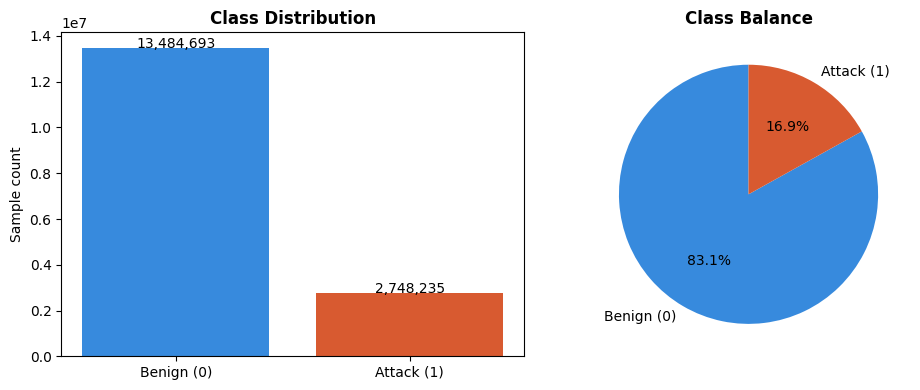

In [7]:
# Cell 7 — Class distribution plot
import matplotlib.pyplot as plt

labels = ["Benign (0)", "Attack (1)"]
counts = [int((y_full == 0).sum()), int((y_full == 1).sum())]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, counts, color=["#378ADD", "#D85A30"])
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Sample count")
for i, c in enumerate(counts):
    axes[0].text(i, c + 5000, f"{c:,}", ha="center")

axes[1].pie(counts, labels=labels,
            colors=["#378ADD", "#D85A30"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Balance", fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/graphs/01_class_distribution.png", dpi=150)
plt.show()

In [ ]:
!pip install matplotlib


In [ ]:

import sys
!{sys.executable} -m pip install matplotlib